### Part 1 - AURA Projections

One of the most common question regarding AURA datasets is:

"What projection do you use / How do I calculate the lat/lon"

The project information is detailed in the metadata, but can be difficult to find and interpret.

Transforming the dataset coordinates into lat/lon geographic coordinates can also be quite simple, if you know where to start!

#### AURA projections overivew

| Dataset | Coordinates | How to transform to lat/lon |
| :-------: | :------: | :-------: |
| Level 1 | Spherical coordinates (azimuth, range, elevation) | pyart or pyodim |
| Level 1b ppi | Spherical coordinates (azimuth, range, elevation) | pyart |
| Level 1b grid | Azimuthal equidistant | pyart |
| Level 2 | Azimuthal equidistant | provided in file! |
| QPE | Albers Equal Area  | pyproj |

Let's look into these in more detail

In [18]:
import pyodim
import pyart
import netCDF4

#Level 1
#pyodim generates the latlon coordinates automatically
datasets = pyodim.read_odim('level_1_example.h5', lazy_load=False)
print(datasets[0]) # show data from first sweep

<xarray.Dataset> Size: 3MB
Dimensions:    (azimuth: 360, range: 254, elevation: 1, time: 360)
Coordinates:
  * azimuth    (azimuth) float32 1kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * range      (range) float32 1kB 2.5e+03 3.5e+03 ... 2.545e+05 2.555e+05
  * elevation  (elevation) float32 4B 0.5
  * time       (time) datetime64[ns] 3kB 2014-11-27T06:02:06.484679665 ... 20...
Data variables:
    DBZH       (azimuth, range) float64 732kB nan nan nan nan ... nan nan nan
    x          (azimuth, range) float32 366kB -0.0001093 ... -4.459e+03
    y          (azimuth, range) float32 366kB 2.5e+03 3.5e+03 ... 2.555e+05
    z          (azimuth, range) float64 732kB 393.8 402.5 ... 2.602e+03
    longitude  (azimuth, range) float32 366kB 152.5 152.5 152.5 ... 152.5 152.5
    latitude   (azimuth, range) float32 366kB -27.58 -27.57 ... -25.31 -25.3
Attributes: (12/15)
    Conventions:  ODIM_H5/V2_2
    latitude:     -27.6064
    longitude:    152.5401
    height:       372.0
    date:     

In [14]:
#so does pyart!
radar = pyart.aux_io.read_odim_h5('level_1_example.h5')
radar.get_gate_lat_lon_alt(0) # latlon for first sweep

(array([[-27.58391786, -27.57492504, -27.56593224, ..., -25.32797479,
         -25.31899455, -25.3100145 ],
        [-27.58392129, -27.57492983, -27.5659384 , ..., -25.32831488,
         -25.31933596, -25.31035722],
        [-27.58393156, -27.57494421, -27.56595688, ..., -25.32933515,
         -25.32036017, -25.31138538],
        ...,
        [-27.58394867, -27.57496816, -27.56598768, ..., -25.33103536,
         -25.32206695, -25.31309872],
        [-27.58393156, -27.57494421, -27.56595688, ..., -25.32933515,
         -25.32036017, -25.31138538],
        [-27.58392129, -27.57492983, -27.5659384 , ..., -25.32831488,
         -25.31933596, -25.31035722]], shape=(360, 254)),
 array([[152.5401    , 152.5401    , 152.5401    , ..., 152.5401    ,
         152.5401    , 152.5401    ],
        [152.54054269, 152.54071971, 152.5408967 , ..., 152.5840814 ,
         152.58425139, 152.58442134],
        [152.54098524, 152.54133923, 152.54169316, ..., 152.62805018,
         152.6283901 , 152.628729

In [17]:
radar = pyart.io.read('level_1b_ppi_example.nc')
radar.get_gate_lat_lon_alt(0) # latlon for first sweep

grid = pyart.io.read_grid('level_1b_grid_example.nc')
grid.get_point_longitude_latitude(0) # latlon for lowest level (0.5 km)

(array([[150.99750186, 151.00777742, 151.01805299, ..., 154.05994701,
         154.07022258, 154.08049814],
        [150.99763378, 151.00790846, 151.01818315, ..., 154.05981685,
         154.07009154, 154.08036622],
        [150.99776565, 151.00803945, 151.01831327, ..., 154.05968673,
         154.06996055, 154.08023435],
        ...,
        [151.03476005, 151.04478738, 151.05481473, ..., 154.02318527,
         154.03321262, 154.04323995],
        [151.0348784 , 151.04490494, 151.0549315 , ..., 154.0230685 ,
         154.03309506, 154.0431216 ],
        [151.0349967 , 151.04502245, 151.05504823, ..., 154.02295177,
         154.03297755, 154.0430033 ]], shape=(301, 301)),
 array([[-28.9484476 , -28.94856101, -28.94867367, ..., -28.94867367,
         -28.94856101, -28.9484476 ],
        [-28.93945595, -28.93956934, -28.93968198, ..., -28.93968198,
         -28.93956934, -28.93945595],
        [-28.9304643 , -28.93057767, -28.93069029, ..., -28.93069029,
         -28.93057767, -28.930464

In [ ]:
# AURA level 2 example
with netCDF4.Dataset('level_2_example.nc') as nc:
    print(nc.variables['latitude'][:])
    print(nc.variables['longitude'][:])

[[-27.037354 -27.037415 -27.037537 ... -27.037537 -27.037415 -27.037354]
 [-27.02832  -27.028442 -27.028564 ... -27.028564 -27.028442 -27.02832 ]
 [-27.019348 -27.01947  -27.019531 ... -27.019531 -27.01947  -27.019348]
 ...
 [-24.357788 -24.35785  -24.357971 ... -24.357971 -24.35785  -24.357788]
 [-24.348755 -24.348877 -24.348999 ... -24.348999 -24.348877 -24.348755]
 [-24.339783 -24.339905 -24.339966 ... -24.339966 -24.339905 -24.339783]]
[[148.38379 148.39392 148.40399 ... 151.3924  151.40253 151.4126 ]
 [148.38391 148.39404 148.40411 ... 151.39227 151.4024  151.41248]
 [148.38403 148.3941  148.40424 ... 151.39215 151.40228 151.41235]
 ...
 [148.41754 148.42737 148.43726 ... 151.35913 151.36902 151.3789 ]
 [148.4176  148.42749 148.43738 ... 151.35907 151.3689  151.37878]
 [148.41772 148.42761 148.43744 ... 151.35895 151.36877 151.37866]]


In [ ]:
# Rainfields 3 projection example - a little more complicated

import xarray as xr
import numpy as np
import pyproj

rainfields_file_path = 'QPE_example.nc'

#open rainfields 3 file and extract necessary variables
with xr.open_dataset(rainfields_file_path) as ds:
    radar_lat = ds.proj.latitude_of_projection_origin
    radar_lon = ds.proj.longitude_of_central_meridian
    x_grid, y_grid = np.meshgrid(ds.x.data, ds.y.data)
    reflectivity = ds.reflectivity.data

print(ds.proj)

<xarray.DataArray 'proj' ()> Size: 1B
[1 values with dtype=int8]
Attributes:
    grid_mapping_name:              albers_conical_equal_area
    standard_parallel:              [-36.3 -39.4]
    longitude_of_central_meridian:  144.752
    latitude_of_projection_origin:  -37.852
    false_easting:                  0.0
    false_northing:                 0.0
    semi_major_axis:                6378137.0
    semi_minor_axis:                6356752.31414


The Albers equal-area conic projection is a map projection that preserves the true area of landmasses, making it useful for maps where accurate area representation is critical, such as those showing population, land use or rainfall!

In [ ]:
#create latlon projection using pyproj and the albers equal area parameters from the file
proj = pyproj.Proj(proj='aea', lat_1=ds.proj.standard_parallel[0], lat_2=ds.proj.standard_parallel[1],
                        lat_0=ds.proj.latitude_of_projection_origin, lon_0=ds.proj.longitude_of_central_meridian,
                        x_0=0, y_0=0)
#convert x,y grid to lat, lon (assuming units of km - be sure to check this though!)
lon_grid, lat_grid = proj(x_grid*1000, y_grid*1000, inverse=True)

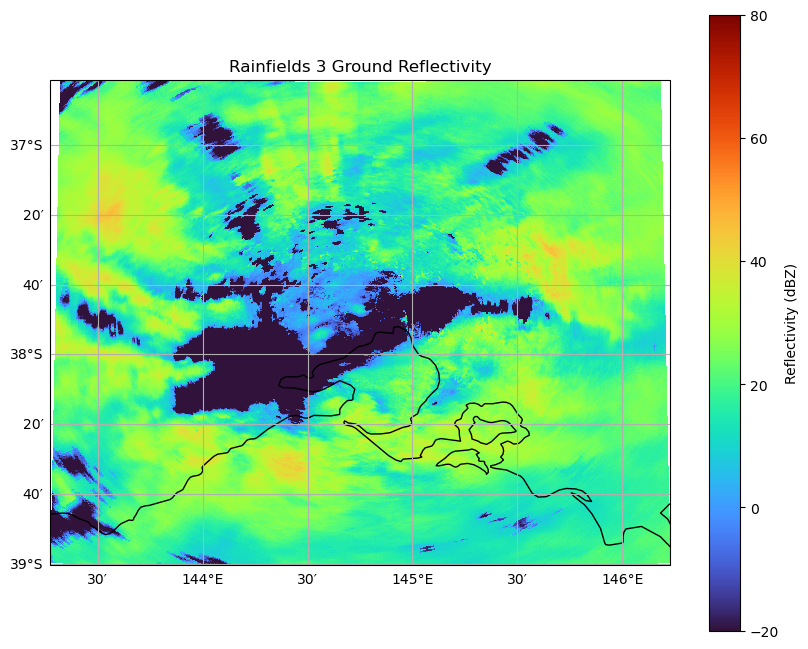

In [7]:
#plot reflectivity on a map using cartopy
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='10m')

sc = ax.pcolormesh(lon_grid, lat_grid, reflectivity, transform=ccrs.PlateCarree(), cmap='turbo', vmin=-20, vmax=80)
# add gridlines and labels with decimal degree formatting
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(sc, label='Reflectivity (dBZ)')
ax.set_title('Rainfields 3 Ground Reflectivity')
plt.show()

The projection is constant for a radar. So once it's loaded and transformed you can reuse it on all files.

# Task

Adapt parts 1 and 2 to generate a comparison of accumulated rainfall between 00-06Z and the 06-12Z for Tropical Cyclone Alfred as it crossed the coast of SEQ.

Radar: 66 (Mt Stapylon)
Date: 8 March 2025
Offshore time period: 00-06Z
Onshore time period: 06-12Z
QPE Product: Rainfields 3 Accumulated Rainfall (prcp-m15)
AURA file: https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/66/2025/prcp-m15/66_20250308.prcp-m15.zip

Make sure to adapt the time filtering and only extract what you need into memory!

Hint: Six hour accumulation plots can be generated by sequentially opening each dataset and using a sum function to append to the previous timestep.

More on Rainfields in the final part of today's workshop.